# 20 — Demand Forecasting: City vs Resort (statsmodels)

Clone chu trình notebook **18** (Workflow 4), nhưng **fit & forecast riêng** cho từng hotel:

| Segment | Ghi chú |
|---------|---------|
| **City Hotel** | Demand đô thị / midweek |
| **Resort Hotel** | Demand nghỉ dưỡng / seasonality mạnh hơn |

1. Plot series + seasonality (per hotel)
2. Stationarity (**ADF**, **KPSS**)
3. ACF / PACF
4. **SARIMAX** (AIC/BIC) + **Holt–Winters**
5. Residual diagnostics
6. Holdout vs **Seasonal Naive**
7. 6-month forecast + CI
8. Dynamic pricing stance
9. So sánh City vs Resort

**Phạm vi:** stay demand `is_canceled = 0` · monthly bookings · ~26 tháng/hotel (2015-07 → 2017-08).
**Output:** `reports/figures/20/{city,resort}/` + bảng so sánh tổng hợp.


In [1]:
import os
import warnings
from itertools import product
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display as ipy_display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "20"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
SEASON = 12
HOLDOUT = 6
HOTELS = ["City Hotel", "Resort Hotel"]
HOTEL_COLORS = {"City Hotel": "#4C72B0", "Resort Hotel": "#55A868"}
TARGET_KIND = "demand"  # demand | adr | revpar
METRIC_LABEL = "Demand (bookings)"
YLABEL = "Bookings"

print(f"statsmodels {sm.__version__}")
print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")
print(f"Target: {METRIC_LABEL} | split: City vs Resort")


statsmodels 0.14.6
ROOT: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\20
Target: Demand (bookings) | split: City vs Resort


In [2]:
def fmt_num(n, d: int = 1) -> str:
    return f"{float(n):,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_int(n) -> str:
    return f"{int(round(n)):,}".replace(",", ".")


def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))


def load_monthly_demand_by_hotel() -> dict[str, pd.Series]:
    df = pd.read_csv(DATA_PATH)
    stay = df[df["is_canceled"] == 0].copy()
    stay["month_num"] = stay["arrival_date_month"].map(MONTH_MAP)
    stay["ym"] = pd.to_datetime(
        dict(year=stay["arrival_date_year"], month=stay["month_num"], day=1)
    )
    out = {}
    for hotel in HOTELS:
        g = stay[stay["hotel"] == hotel]
        y = (
            g.groupby("ym").size()
            .rename("bookings")
            .astype(float)
            .asfreq("MS")
            .fillna(0.0)
        )
        out[hotel] = y
        print(
            f"{hotel}: months={len(y)} | total bookings={fmt_int(y.sum())} | "
            f"mean/mo={fmt_num(y.mean(), 1)}"
        )
    return out


series_by_hotel = load_monthly_demand_by_hotel()
by_hotel = pd.concat(
    [s.rename("bookings").to_frame().assign(hotel=h) for h, s in series_by_hotel.items()],
    ignore_index=False,
).reset_index()


City Hotel: months=26 | total bookings=35.137 | mean/mo=1.351,4
Resort Hotel: months=26 | total bookings=24.390 | mean/mo=938,1


## 0. Overview — City vs Resort


Saved: reports\figures\20\00_overview_city_vs_resort.png


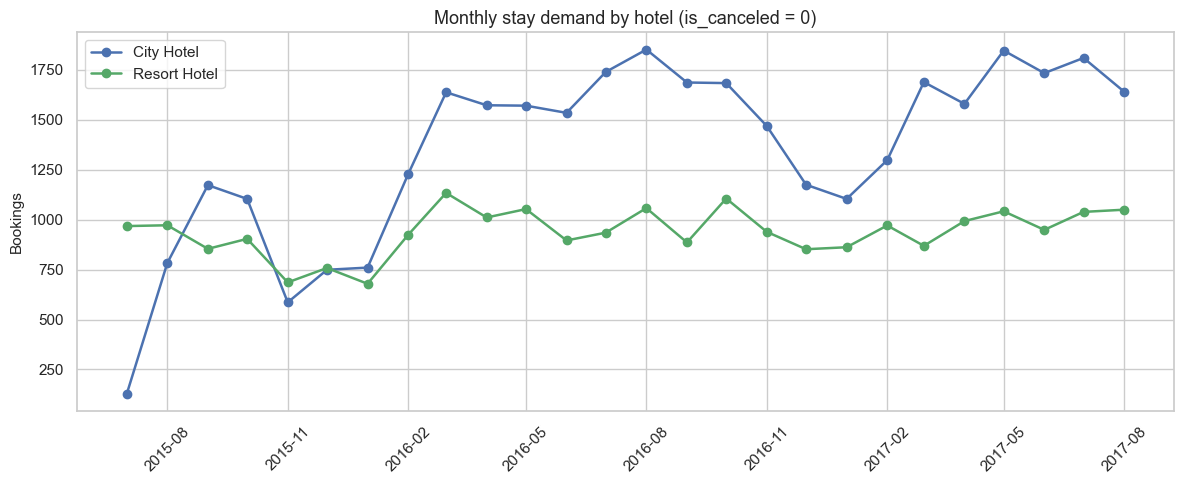

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
for hotel in HOTELS:
    y = series_by_hotel[hotel]
    ax.plot(y.index, y.values, marker="o", lw=1.8, label=hotel, color=HOTEL_COLORS[hotel])
ax.set_ylabel("Bookings")
ax.set_title("Monthly stay demand by hotel (is_canceled = 0)")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
path = FIG_DIR / "00_overview_city_vs_resort.png"
plt.savefig(path, dpi=140, bbox_inches="tight")
print(f"Saved: {path.relative_to(ROOT)}")
plt.show()


## Pipeline helpers (Workflow 4 — giống notebook 18)


In [4]:
def hotel_slug(hotel: str) -> str:
    return "city" if hotel == "City Hotel" else "resort"


def savefig_hotel(name: str, slug: str) -> Path:
    path = FIG_DIR / slug / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def stationarity_report(series: pd.Series, name: str) -> dict:
    series = series.dropna().astype(float)
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    except Exception as e:
        kpss_stat, kpss_p = np.nan, np.nan
        print(f"KPSS warning ({name}): {e}")
    return {
        "series": name,
        "n": len(series),
        "adf_stat": adf_stat,
        "adf_pvalue": adf_p,
        "adf_stationary_5pct": adf_p < 0.05,
        "kpss_stat": kpss_stat,
        "kpss_pvalue": kpss_p,
        "kpss_stationary_5pct": kpss_p >= 0.05 if pd.notna(kpss_p) else np.nan,
    }


def pick_diff_orders(stat_df: pd.DataFrame) -> tuple[int, int]:
    for name, d, D in [
        ("diff1", 1, 0),
        ("seasonal_diff12", 0, 1),
        ("diff1_seasonal12", 1, 1),
        ("level", 0, 0),
    ]:
        row = stat_df.loc[stat_df["series"] == name].iloc[0]
        adf_ok = bool(row["adf_stationary_5pct"])
        kpss_ok = bool(row["kpss_stationary_5pct"]) if pd.notna(row["kpss_stationary_5pct"]) else False
        if adf_ok and kpss_ok:
            return d, D
    return 0, 1


def fit_sarimax(series, order, seasonal_order):
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


def fit_holt_winters(series: pd.Series, label: str = "series"):
    n = len(series)
    if n >= 2 * SEASON:
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal="add",
            seasonal_periods=SEASON,
            initialization_method="estimated",
        )
        kind = "holt_winters_seasonal"
    else:
        print(f"[{label}] n={n} < {2 * SEASON}: seasonal HW unavailable -> Holt trend-only")
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal=None,
            initialization_method="estimated",
        )
        kind = "holt_trend"
    return model.fit(optimized=True), kind


def seasonal_naive(history: pd.Series, steps: int) -> np.ndarray:
    out, cur = [], history.astype(float).copy()
    for _ in range(steps):
        pred = float(cur.iloc[-SEASON]) if len(cur) >= SEASON else float(cur.mean())
        out.append(pred)
        cur = pd.concat([cur, pd.Series([pred], index=[cur.index[-1] + pd.offsets.MonthBegin(1)])])
    return np.asarray(out)


def _format_resid_time_axis(ax) -> None:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")


def lb_p(df, lag):
    return float(df.loc[lag, "lb_pvalue"]) if lag in df.index else np.nan


def run_forecast_pipeline(y: pd.Series, hotel: str, ylabel: str, metric_label: str) -> dict:
    """Full Workflow 4 from notebook 18 series, scoped to one hotel."""
    slug = hotel_slug(hotel)
    color = HOTEL_COLORS[hotel]
    print("=" * 72)
    print(f"{metric_label} FORECAST — {hotel}")
    print("=" * 72)
    print(f"Months: {len(y)} | {y.index.min().date()} → {y.index.max().date()}")

    # 1. Plot + decompose
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y.index, y.values, marker="o", lw=1.8, color=color)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Monthly {metric_label} — {hotel}")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    savefig_hotel("01_monthly_series.png", slug)
    plt.show()

    decomp = seasonal_decompose(y, model="additive", period=SEASON)
    fig = decomp.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"seasonal_decompose — {hotel} ({metric_label})", y=1.02)
    savefig_hotel("02_seasonal_decompose.png", slug)
    plt.show()

    # 2. Stationarity
    candidates = {
        "level": y,
        "diff1": y.diff().dropna(),
        "seasonal_diff12": y.diff(SEASON).dropna(),
        "diff1_seasonal12": y.diff().diff(SEASON).dropna(),
    }
    stat_df = pd.DataFrame([stationarity_report(s, n) for n, s in candidates.items()])
    display(stat_df.round(4))
    stat_df.to_csv(FIG_DIR / slug / "stationarity_tests.csv", index=False)
    d_order, D_order = pick_diff_orders(stat_df)
    print(f"Selected differencing: d={d_order}, D={D_order} (s={SEASON})")

    # 3. ACF / PACF
    if D_order == 1 and d_order == 1:
        y_acf = y.diff().diff(SEASON).dropna()
    elif D_order == 1:
        y_acf = y.diff(SEASON).dropna()
    elif d_order == 1:
        y_acf = y.diff().dropna()
    else:
        y_acf = y.copy()
    max_lags = min(18, max(6, len(y_acf) // 2 - 1))
    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    plot_acf(y_acf, lags=max_lags, ax=axes[0])
    axes[0].set_title(f"ACF — {hotel} (d={d_order}, D={D_order})")
    plot_pacf(y_acf, lags=max_lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF — {hotel} (d={d_order}, D={D_order})")
    savefig_hotel("03_acf_pacf.png", slug)
    plt.show()

    # 4. SARIMAX grid + HW
    train = y.iloc[:-HOLDOUT]
    test = y.iloc[-HOLDOUT:]
    print(f"Train: {train.index.min().date()} → {train.index.max().date()} (n={len(train)})")
    print(f"Test : {test.index.min().date()} → {test.index.max().date()} (n={len(test)})")

    grid_rows = []
    for p, q, P, Q in product(range(0, 3), range(0, 3), range(0, 2), range(0, 2)):
        order = (p, d_order, q)
        seasonal_order = (P, D_order, Q, SEASON)
        if (p, d_order, q) == (0, 0, 0) and P == 0 and Q == 0:
            continue
        try:
            res = fit_sarimax(train, order, seasonal_order)
            aic_v, bic_v, llf_v = float(res.aic), float(res.bic), float(res.llf)
            if not np.isfinite(aic_v) or not np.isfinite(llf_v):
                continue
            grid_rows.append(
                {
                    "order": str(order),
                    "seasonal_order": str(seasonal_order),
                    "p": p, "d": d_order, "q": q,
                    "P": P, "D": D_order, "Q": Q,
                    "aic": aic_v, "bic": bic_v, "llf": llf_v,
                }
            )
        except Exception:
            continue

    grid = pd.DataFrame(grid_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
    print(f"Fitted {len(grid)} usable SARIMAX candidates on train")
    display(grid.head(10).round(2))
    grid.to_csv(FIG_DIR / slug / "sarimax_aic_grid.csv", index=False)
    if len(grid) == 0:
        raise RuntimeError(f"No SARIMAX candidate for {hotel}")

    best = grid.iloc[0]
    best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
    best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), SEASON)
    print(f"Best SARIMAX by AIC: {best_order} x {best_seasonal} | AIC={best['aic']:.2f}")

    sarimax_train = fit_sarimax(train, best_order, best_seasonal)
    print(sarimax_train.summary())
    hw_train, hw_train_kind = fit_holt_winters(train, "train")
    print(f"Train exponential smoothing kind: {hw_train_kind}")

    # 5. Residual diagnostics
    resid = pd.Series(sarimax_train.resid, index=train.index).dropna()
    diag_lags = max(4, min(8, len(resid) // 3))
    try:
        fig = sarimax_train.plot_diagnostics(figsize=(12, 8), lags=diag_lags)
        fig.suptitle(f"SARIMAX{best_order}x{best_seasonal} — {hotel}", y=1.02)
        _format_resid_time_axis(fig.axes[0])
        savefig_hotel("04_sarimax_diagnostics.png", slug)
        plt.show()
    except ValueError as e:
        print("plot_diagnostics skipped:", e)
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes[0, 0].plot(resid.index, resid.values)
        axes[0, 0].axhline(0, color="r", ls="--")
        axes[0, 0].set_title("Residuals")
        _format_resid_time_axis(axes[0, 0])
        axes[0, 1].hist(resid.values, bins=10, edgecolor="white")
        axes[0, 1].set_title("Residual histogram")
        plot_acf(resid, lags=diag_lags, ax=axes[1, 0])
        sm.qqplot(resid, line="s", ax=axes[1, 1])
        fig.suptitle(f"SARIMAX manual diagnostics — {hotel}", y=1.02)
        savefig_hotel("04_sarimax_diagnostics.png", slug)
        plt.show()

    lb_lags = [lag for lag in [3, 6, 12] if lag < len(resid)]
    lb = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
    hw_resid = pd.Series(train - hw_train.fittedvalues, index=train.index).dropna()
    lb_hw = acorr_ljungbox(
        hw_resid, lags=[lag for lag in [3, 6, 12] if lag < len(hw_resid)], return_df=True
    )
    diag_summary = pd.DataFrame(
        {
            "model": ["SARIMAX", hw_train_kind],
            "ljungbox_lag6_pvalue": [lb_p(lb, 6), lb_p(lb_hw, 6)],
            "ljungbox_lag12_pvalue": [lb_p(lb, 12), lb_p(lb_hw, 12)],
            "resid_mean": [resid.mean(), hw_resid.mean()],
            "resid_std": [resid.std(), hw_resid.std()],
        }
    )
    display(diag_summary.round(4))
    diag_summary.to_csv(FIG_DIR / slug / "residual_diagnostics.csv", index=False)

    # 6. Holdout
    fc_naive = seasonal_naive(train, HOLDOUT)
    fc_hw = np.asarray(hw_train.forecast(HOLDOUT), dtype=float)
    hw_holdout_label = hw_train_kind
    sarimax_fc = sarimax_train.get_forecast(steps=HOLDOUT)
    fc_sarimax = np.asarray(sarimax_fc.predicted_mean, dtype=float)
    ci_sarimax = sarimax_fc.conf_int(alpha=0.05)
    ci_sarimax.columns = ["lower_95", "upper_95"]

    holdout = pd.DataFrame(
        {
            "ym": test.index,
            "actual": test.values,
            "seasonal_naive": fc_naive,
            hw_holdout_label: fc_hw,
            "sarimax": fc_sarimax,
            "sarimax_lower95": ci_sarimax["lower_95"].values,
            "sarimax_upper95": ci_sarimax["upper_95"].values,
        }
    )
    for c in ["seasonal_naive", hw_holdout_label, "sarimax", "sarimax_lower95"]:
        holdout[c] = holdout[c].clip(lower=0)

    display(holdout.round(2))
    metrics = []
    for name in ["seasonal_naive", hw_holdout_label, "sarimax"]:
        metrics.append(
            {
                "model": name,
                "MAE": mae(holdout["actual"], holdout[name]),
                "RMSE": rmse(holdout["actual"], holdout[name]),
                "MAPE": mape(holdout["actual"], holdout[name]),
            }
        )
    metrics_df = pd.DataFrame(metrics).sort_values("MAPE").reset_index(drop=True)
    display(metrics_df.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "MAPE": "{:.2%}"}))
    metrics_df.to_csv(FIG_DIR / slug / "holdout_metrics.csv", index=False)
    holdout.to_csv(FIG_DIR / slug / "holdout_forecast_detail.csv", index=False)

    best_model = metrics_df.iloc[0]["model"]
    inside = (
        (holdout["actual"] >= holdout["sarimax_lower95"])
        & (holdout["actual"] <= holdout["sarimax_upper95"])
    ).mean()
    print(f"Best holdout model (MAPE): {best_model}")
    print(f"SARIMAX 95% PI coverage on holdout: {inside:.1%}")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
    ax.plot(holdout["ym"], holdout["seasonal_naive"], ls="--", label="Seasonal Naive")
    ax.plot(holdout["ym"], holdout[hw_holdout_label], ls=":", label=hw_holdout_label)
    ax.plot(holdout["ym"], holdout["sarimax"], marker="o", label=f"SARIMAX{best_order}x{best_seasonal}")
    ax.fill_between(
        holdout["ym"], holdout["sarimax_lower95"], holdout["sarimax_upper95"],
        color="#e07a5f", alpha=0.2, label="SARIMAX 95% PI",
    )
    ax.axvline(train.index.max(), color="gray", ls="--", lw=1)
    ax.set_title(f"Holdout — {hotel} ({metric_label})")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    savefig_hotel("05_holdout_forecasts.png", slug)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=metrics_df, x="model", y="MAPE", hue="model", legend=False, ax=ax)
    ax.set_title(f"Holdout MAPE — {hotel}")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.tick_params(axis="x", rotation=15)
    savefig_hotel("05_holdout_metrics.png", slug)
    plt.show()

    # 7. Refit full + horizon
    HORIZON = 6
    sarimax_full = fit_sarimax(y, best_order, best_seasonal)
    hw_full, hw_full_kind = fit_holt_winters(y, "full")
    print(f"Full-sample exponential smoothing kind: {hw_full_kind}")

    full_resid_n = len(pd.Series(sarimax_full.resid).dropna())
    full_lags = max(4, min(10, full_resid_n // 3))
    try:
        fig = sarimax_full.plot_diagnostics(figsize=(12, 8), lags=full_lags)
        fig.suptitle(f"Full-sample SARIMAX — {hotel}", y=1.02)
        savefig_hotel("06_sarimax_full_diagnostics.png", slug)
        plt.show()
    except ValueError as e:
        print("Full-sample plot_diagnostics skipped:", e)

    fc_obj = sarimax_full.get_forecast(steps=HORIZON)
    fc_mean = fc_obj.predicted_mean.clip(lower=0)
    fc_ci = fc_obj.conf_int(alpha=0.05)
    fc_ci.columns = ["lower_95", "upper_95"]
    fc_ci["lower_95"] = fc_ci["lower_95"].clip(lower=0)
    fc_hw = pd.Series(hw_full.forecast(HORIZON), index=fc_mean.index).clip(lower=0)
    fc_naive_h = pd.Series(seasonal_naive(y, HORIZON), index=fc_mean.index)

    forecast_df = pd.DataFrame(
        {
            "hotel": hotel,
            "ym": fc_mean.index,
            "sarimax": fc_mean.values,
            "sarimax_lower95": fc_ci["lower_95"].values,
            "sarimax_upper95": fc_ci["upper_95"].values,
            "holt_winters": fc_hw.values,
            "holt_kind_full": hw_full_kind,
            "seasonal_naive": fc_naive_h.values,
            "best_holdout_model": best_model,
            "sarimax_order": str(best_order),
            "sarimax_seasonal_order": str(best_seasonal),
        }
    )
    display(forecast_df.round(2))
    forecast_df.to_csv(FIG_DIR / slug / "forecast_next_6m.csv", index=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
    ax.plot(forecast_df["ym"], forecast_df["sarimax"], marker="o", color="#e07a5f", label="SARIMAX")
    ax.fill_between(
        forecast_df["ym"], forecast_df["sarimax_lower95"], forecast_df["sarimax_upper95"],
        color="#e07a5f", alpha=0.2, label="95% PI",
    )
    ax.plot(forecast_df["ym"], forecast_df["holt_winters"], ls=":", label="Holt-Winters")
    ax.plot(forecast_df["ym"], forecast_df["seasonal_naive"], ls="--", label="Seasonal Naive")
    ax.axvline(y.index.max(), color="gray", ls="--", lw=1)
    ax.set_title(f"6-month forecast — {hotel} | SARIMAX{best_order}x{best_seasonal}")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    savefig_hotel("07_forecast_horizon.png", slug)
    plt.show()

    # 8. Pricing / rate stance
    month_mean = y.groupby(y.index.month).mean()
    season_index = (month_mean / month_mean.mean()).rename("season_index")
    if best_model == "seasonal_naive":
        fc_col = "seasonal_naive"
    elif best_model == "sarimax":
        fc_col = "sarimax"
    else:
        fc_col = "holt_winters"

    grand = float(month_mean.mean())
    pricing = forecast_df[["ym", fc_col]].copy().rename(columns={fc_col: "forecast"})
    pricing["hotel"] = hotel
    pricing["month"] = pricing["ym"].dt.month
    pricing["season_index"] = pricing["month"].map(season_index)
    pricing["metric_index"] = pricing["forecast"] / grand
    pricing["combined_pressure"] = 0.5 * pricing["season_index"] + 0.5 * pricing["metric_index"]

    if TARGET_KIND == "demand":
        STANCE_HIGH = "PROTECT — raise / harden BAR, limit promo"
        STANCE_LOW = "STIMULATE — promo / early-bird / package"
        STANCE_MID = "NEUTRAL — hold BAR, tactical weekend premium"
        index_name = "demand_index"
    else:
        STANCE_HIGH = "PROTECT — harden BAR / limit discounting"
        STANCE_LOW = "STIMULATE — promo / early-bird / package"
        STANCE_MID = "NEUTRAL — hold BAR, tactical weekend premium"
        index_name = "metric_index"

    pricing = pricing.rename(columns={"metric_index": index_name})

    def stance(row) -> str:
        if row["combined_pressure"] >= 1.15:
            return STANCE_HIGH
        if row["combined_pressure"] <= 0.90:
            return STANCE_LOW
        return STANCE_MID

    pricing["pricing_stance"] = pricing.apply(stance, axis=1)
    pricing["forecast_model"] = best_model
    cols = [
        "hotel", "ym", "forecast_model", "forecast", "season_index",
        index_name, "combined_pressure", "pricing_stance",
    ]
    display(pricing[cols].round(3))
    pricing[cols].to_csv(FIG_DIR / slug / "pricing_stance_forecast.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = pricing["pricing_stance"].map(
        {STANCE_HIGH: "#c1121f", STANCE_LOW: "#2a9d8f", STANCE_MID: "#e9c46a"}
    )
    ax.bar(pricing["ym"].dt.strftime("%Y-%m"), pricing["combined_pressure"], color=colors)
    ax.axhline(1.15, color="#c1121f", ls="--", lw=1, label="Protect")
    ax.axhline(0.90, color="#2a9d8f", ls="--", lw=1, label="Stimulate")
    ax.axhline(1.0, color="gray", ls=":", lw=1)
    ax.set_title(f"Pressure — {hotel} (via {best_model})")
    ax.set_ylabel("Index")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    savefig_hotel("08_pricing_stance.png", slug)
    plt.show()

    # 9. KPI
    mape_map = metrics_df.set_index("model")["MAPE"].to_dict()
    kpi = pd.DataFrame(
        [
            {"hotel": hotel, "metric": "n_months", "value": len(y)},
            {"hotel": hotel, "metric": "series_sum_or_mean", "value": round(float(y.sum() if TARGET_KIND == "demand" else y.mean()), 4)},
            {"hotel": hotel, "metric": "diff_d", "value": d_order},
            {"hotel": hotel, "metric": "diff_D", "value": D_order},
            {"hotel": hotel, "metric": "sarimax_order", "value": str(best_order)},
            {"hotel": hotel, "metric": "sarimax_seasonal_order", "value": str(best_seasonal)},
            {"hotel": hotel, "metric": "sarimax_aic_train", "value": round(float(best["aic"]), 2)},
            {"hotel": hotel, "metric": "best_holdout_model", "value": best_model},
            {"hotel": hotel, "metric": "best_holdout_mape", "value": round(float(metrics_df.iloc[0]["MAPE"]), 4)},
            {"hotel": hotel, "metric": "naive_holdout_mape", "value": round(float(mape_map.get("seasonal_naive", np.nan)), 4)},
            {"hotel": hotel, "metric": "hw_holdout_kind", "value": hw_holdout_label},
            {"hotel": hotel, "metric": "hw_full_kind", "value": hw_full_kind},
            {"hotel": hotel, "metric": "sarimax_holdout_mape", "value": round(float(mape_map.get("sarimax", np.nan)), 4)},
            {"hotel": hotel, "metric": "sarimax_pi95_coverage", "value": round(float(inside), 4)},
            {"hotel": hotel, "metric": "forecast_horizon_months", "value": HORIZON},
        ]
    )
    display(kpi)
    kpi.to_csv(FIG_DIR / slug / "kpi_summary.csv", index=False)

    return {
        "hotel": hotel,
        "slug": slug,
        "y": y,
        "metrics_df": metrics_df,
        "best_model": best_model,
        "best_order": best_order,
        "best_seasonal": best_seasonal,
        "d_order": d_order,
        "D_order": D_order,
        "inside": inside,
        "forecast_df": forecast_df,
        "pricing": pricing[cols],
        "kpi": kpi,
        "mape_map": mape_map,
        "hw_holdout_label": hw_holdout_label,
        "aic": float(best["aic"]),
    }


## 1–9. Chạy forecast riêng cho City Hotel & Resort Hotel


Demand (bookings) FORECAST — City Hotel
Months: 26 | 2015-07-01 → 2017-08-01
Saved: reports\figures\20\city\01_monthly_series.png


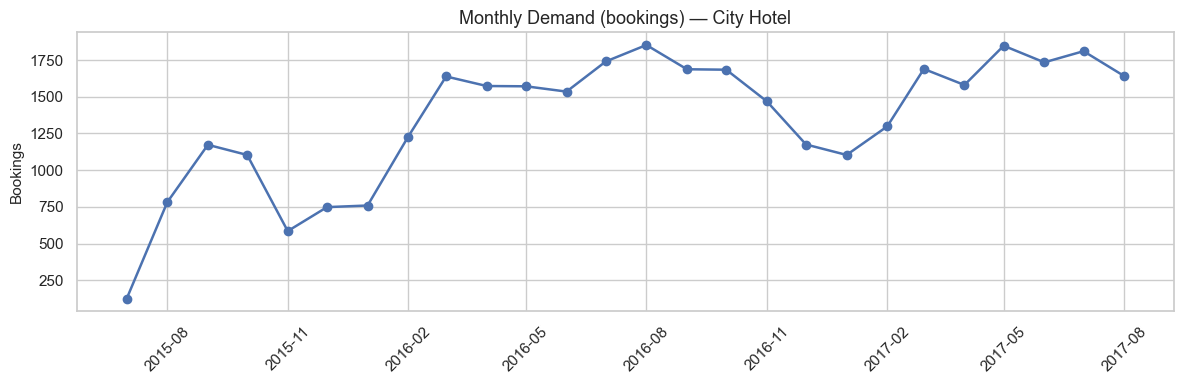

Saved: reports\figures\20\city\02_seasonal_decompose.png


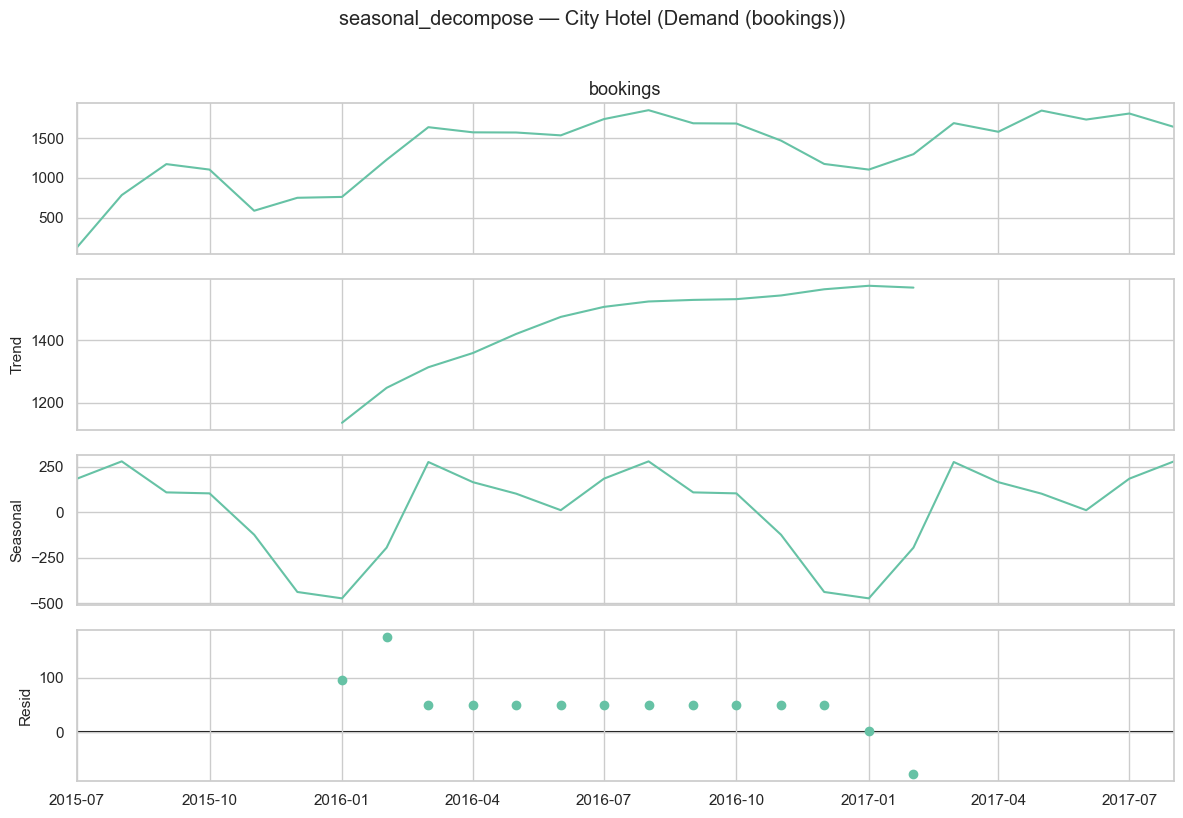

,series,n,adf_stat,adf_pvalue,adf_stationary_5pct,kpss_stat,kpss_pvalue,kpss_stationary_5pct
0,level,26,-3.3887,0.0113,True,0.5245,0.0361,False
1,diff1,25,-4.3233,0.0004,True,0.2040,0.1000,True
2,seasonal_diff12,14,-5.3216,0.0000,True,0.6697,0.0163,False
3,diff1_seasonal12,13,-3.4695,0.0088,True,0.1959,0.1000,True


Selected differencing: d=1, D=0 (s=12)
Saved: reports\figures\20\city\03_acf_pacf.png


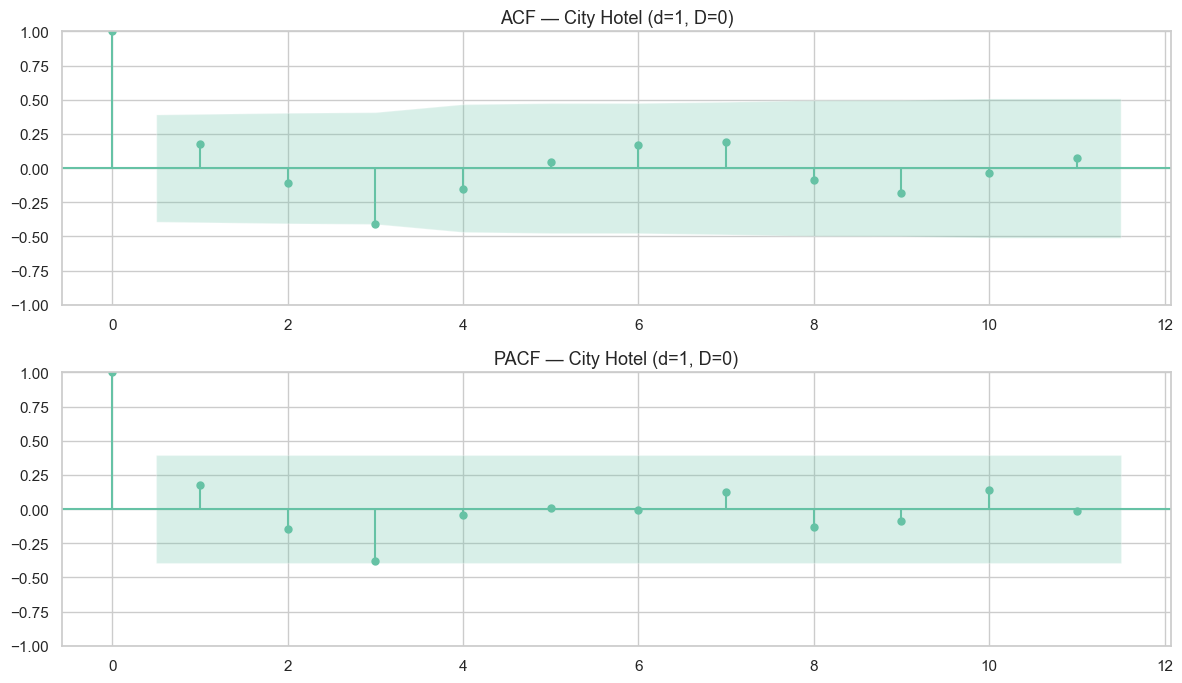

Train: 2015-07-01 → 2017-02-01 (n=20)
Test : 2017-03-01 → 2017-08-01 (n=6)
Fitted 36 usable SARIMAX candidates on train


,order,seasonal_order,p,d,q,P,D,Q,aic,bic,llf
0,"(2, 1, 2)","(1, 0, 1, 12)",2,1,2,1,0,1,54.34,50.04,-20.17
1,"(0, 1, 2)","(0, 0, 1, 12)",0,1,2,0,0,1,57.33,54.88,-24.67
2,"(2, 1, 2)","(0, 0, 1, 12)",2,1,2,0,0,1,58.28,54.60,-23.14
3,"(0, 1, 2)","(1, 0, 1, 12)",0,1,2,1,0,1,59.21,56.14,-24.60
4,"(1, 1, 2)","(0, 0, 1, 12)",1,1,2,0,0,1,60.78,57.71,-25.39
5,"(1, 1, 2)","(1, 0, 1, 12)",1,1,2,1,0,1,60.96,57.27,-24.48
6,"(0, 1, 1)","(0, 0, 1, 12)",0,1,1,0,0,1,70.63,69.46,-32.32
7,"(0, 1, 1)","(1, 0, 1, 12)",0,1,1,1,0,1,71.26,69.70,-31.63
8,"(1, 1, 1)","(0, 0, 1, 12)",1,1,1,0,0,1,72.40,70.84,-32.20
9,"(2, 1, 0)","(1, 0, 0, 12)",2,1,0,1,0,0,72.60,71.03,-32.30


Best SARIMAX by AIC: (2, 1, 2) x (1, 0, 1, 12) | AIC=54.34
                                      SARIMAX Results                                       
Dep. Variable:                             bookings   No. Observations:                   20
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 12)   Log Likelihood                 -20.168
Date:                              Tue, 21 Jul 2026   AIC                             54.337
Time:                                      20:53:32   BIC                             50.041
Sample:                                  07-01-2015   HQIC                            44.910
                                       - 02-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7006    143.245      0

<Figure size 1200x800 with 0 Axes>

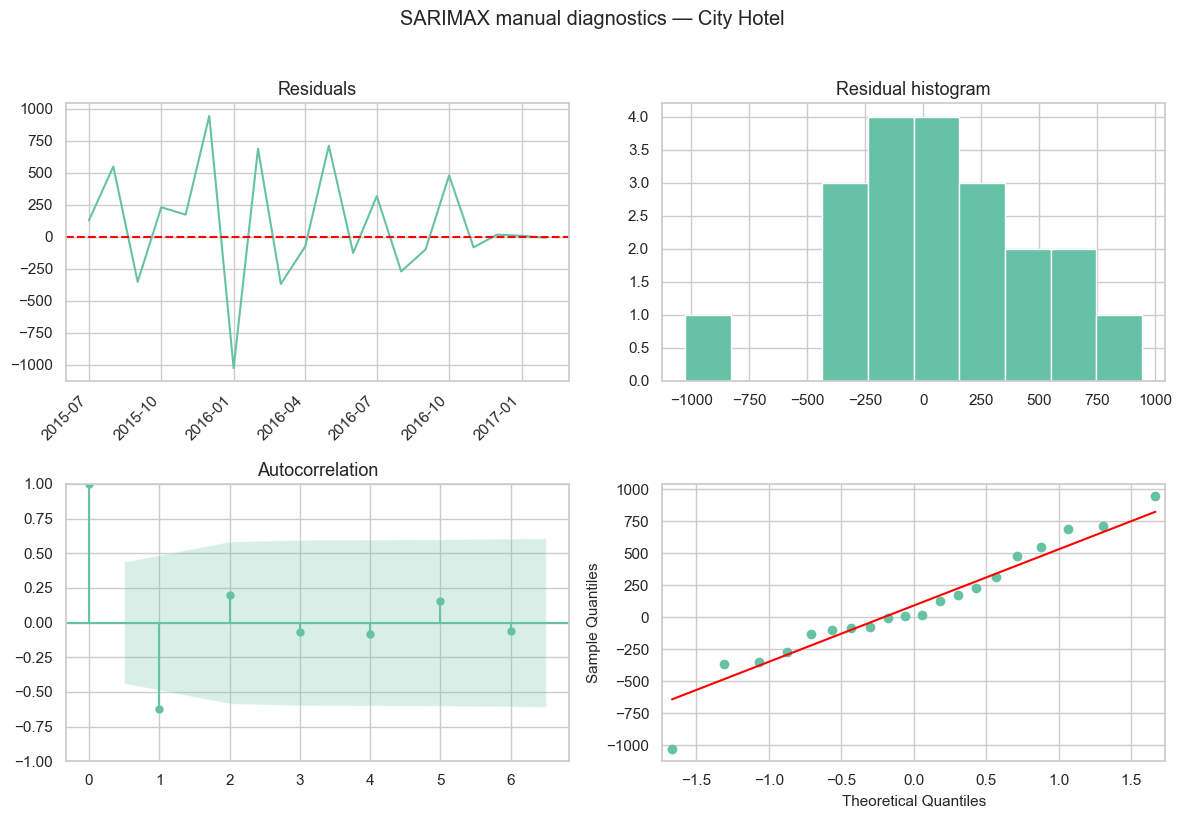

,model,ljungbox_lag6_pvalue,ljungbox_lag12_pvalue,resid_mean,resid_std
0,SARIMAX,0.0867,0.4491,91.2854,450.2723
1,holt_trend,0.1633,0.2630,-0.0002,277.1880


,ym,actual,seasonal_naive,holt_trend,sarimax,sarimax_lower95,sarimax_upper95
0,2017-03-01,1689.0,1638.0,1359.63,1806.85,1737.89,1875.82
1,2017-04-01,1580.0,1573.0,1421.26,2393.75,2274.74,2512.77
2,2017-05-01,1847.0,1571.0,1482.90,2528.76,2378.69,2678.83
3,2017-06-01,1734.0,1535.0,1544.53,1916.36,1762.99,2069.72
4,2017-07-01,1810.0,1740.0,1606.16,634.70,483.47,785.92
5,2017-08-01,1641.0,1852.0,1667.79,0.00,0.00,-380.66


,model,MAE,RMSE,MAPE
0,seasonal_naive,135.67,167.26,7.77%
1,holt_trend,212.05,239.59,12.18%
2,sarimax,768.67,935.27,45.14%


Best holdout model (MAPE): seasonal_naive
SARIMAX 95% PI coverage on holdout: 0.0%
Saved: reports\figures\20\city\05_holdout_forecasts.png


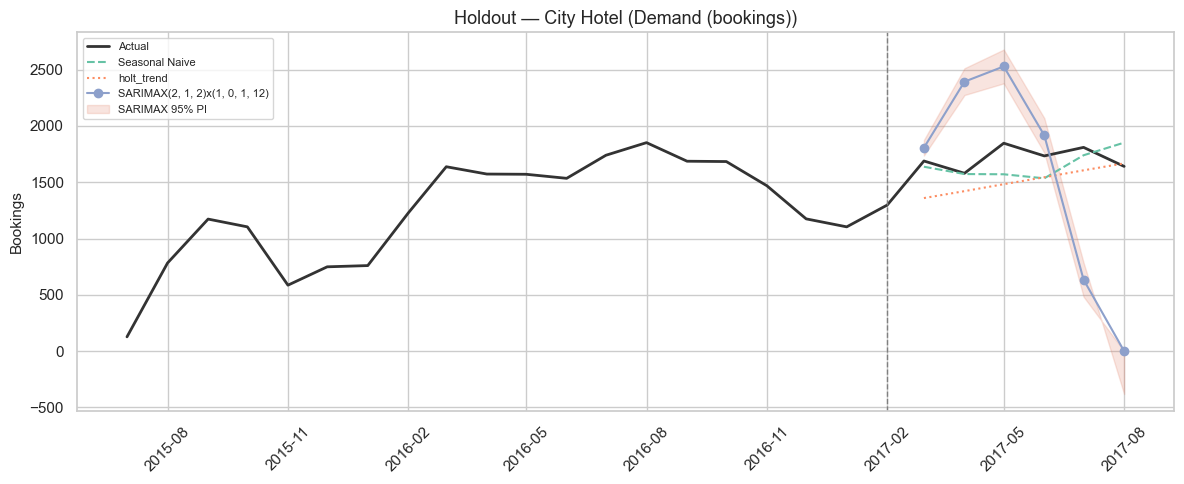

Saved: reports\figures\20\city\05_holdout_metrics.png


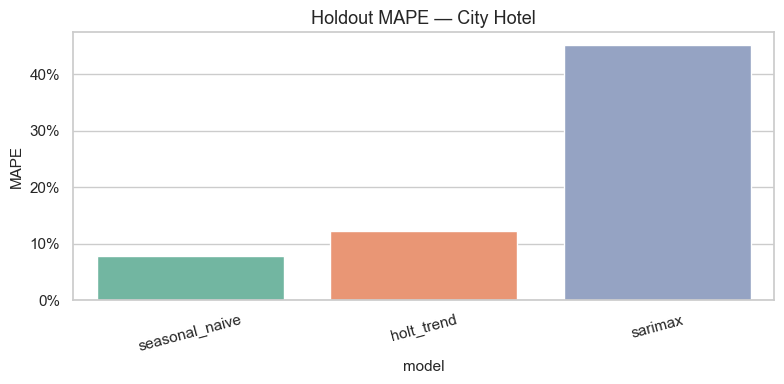

Full-sample exponential smoothing kind: holt_winters_seasonal
Full-sample plot_diagnostics skipped: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.


,hotel,ym,sarimax,sarimax_lower95,sarimax_upper95,holt_winters,holt_kind_full,seasonal_naive,best_holdout_model,sarimax_order,sarimax_seasonal_order
0,City Hotel,2017-09-01,1535.24,1294.72,1775.77,1427.50,holt_winters_seasonal,1687.0,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
1,City Hotel,2017-10-01,1409.45,1086.36,1732.54,1086.95,holt_winters_seasonal,1684.0,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
2,City Hotel,2017-11-01,1283.70,861.44,1705.96,437.23,holt_winters_seasonal,1469.0,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
3,City Hotel,2017-12-01,1000.49,502.65,1498.34,110.30,holt_winters_seasonal,1175.0,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
4,City Hotel,2018-01-01,907.76,355.19,1460.33,0.00,holt_winters_seasonal,1104.0,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
5,City Hotel,2018-02-01,933.46,325.83,1541.10,0.00,holt_winters_seasonal,1298.0,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"


Saved: reports\figures\20\city\07_forecast_horizon.png


<Figure size 1200x800 with 0 Axes>

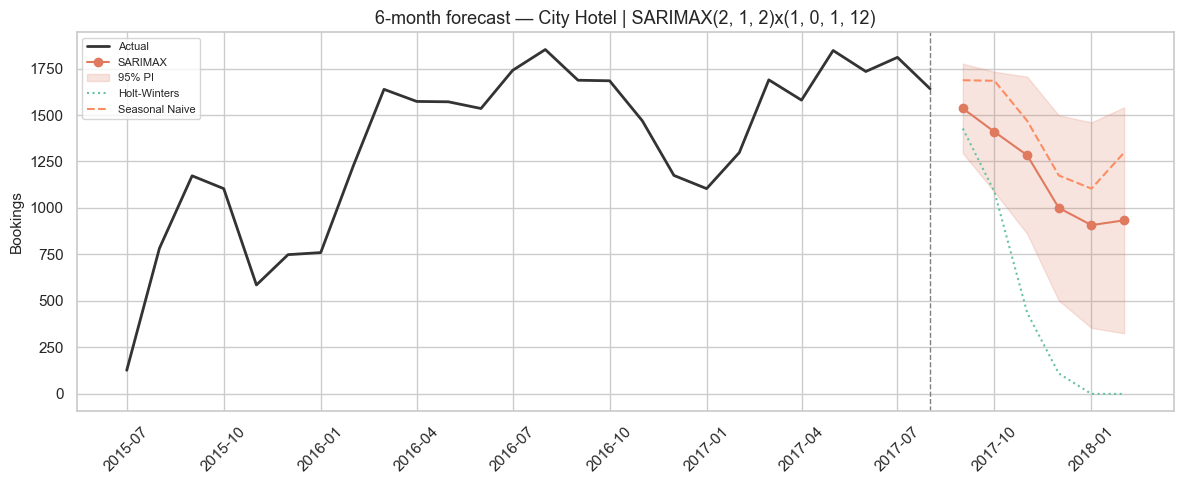

,hotel,ym,forecast_model,forecast,season_index,demand_index,combined_pressure,pricing_stance
0,City Hotel,2017-09-01,seasonal_naive,1687.0,1.056,1.246,1.151,"PROTECT — raise / harden BAR, limit promo"
1,City Hotel,2017-10-01,seasonal_naive,1684.0,1.030,1.244,1.137,"NEUTRAL — hold BAR, tactical weekend premium"
2,City Hotel,2017-11-01,seasonal_naive,1469.0,0.759,1.085,0.922,"NEUTRAL — hold BAR, tactical weekend premium"
3,City Hotel,2017-12-01,seasonal_naive,1175.0,0.711,0.868,0.789,STIMULATE — promo / early-bird / package
4,City Hotel,2018-01-01,seasonal_naive,1104.0,0.689,0.816,0.752,STIMULATE — promo / early-bird / package
5,City Hotel,2018-02-01,seasonal_naive,1298.0,0.933,0.959,0.946,"NEUTRAL — hold BAR, tactical weekend premium"


Saved: reports\figures\20\city\08_pricing_stance.png


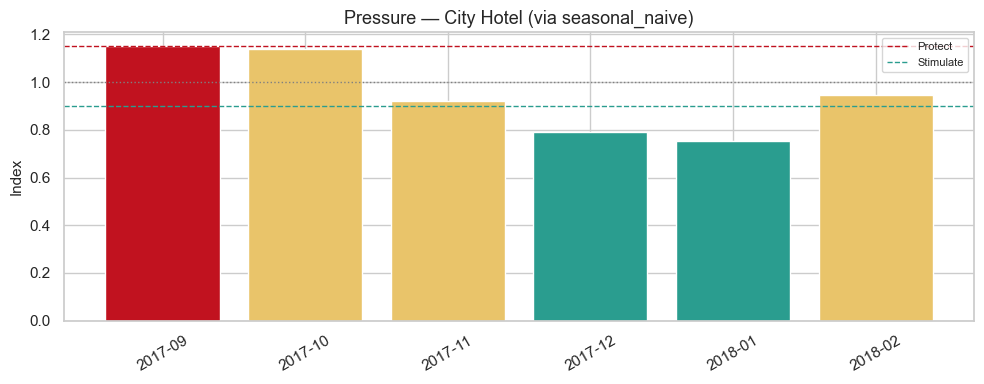

,hotel,metric,value
0,City Hotel,n_months,26
1,City Hotel,series_sum_or_mean,35137.0
2,City Hotel,diff_d,1
3,City Hotel,diff_D,0
4,City Hotel,sarimax_order,"(2, 1, 2)"
5,City Hotel,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,City Hotel,sarimax_aic_train,54.34
7,City Hotel,best_holdout_model,seasonal_naive
8,City Hotel,best_holdout_mape,0.0777
9,City Hotel,naive_holdout_mape,0.0777


Demand (bookings) FORECAST — Resort Hotel
Months: 26 | 2015-07-01 → 2017-08-01
Saved: reports\figures\20\resort\01_monthly_series.png


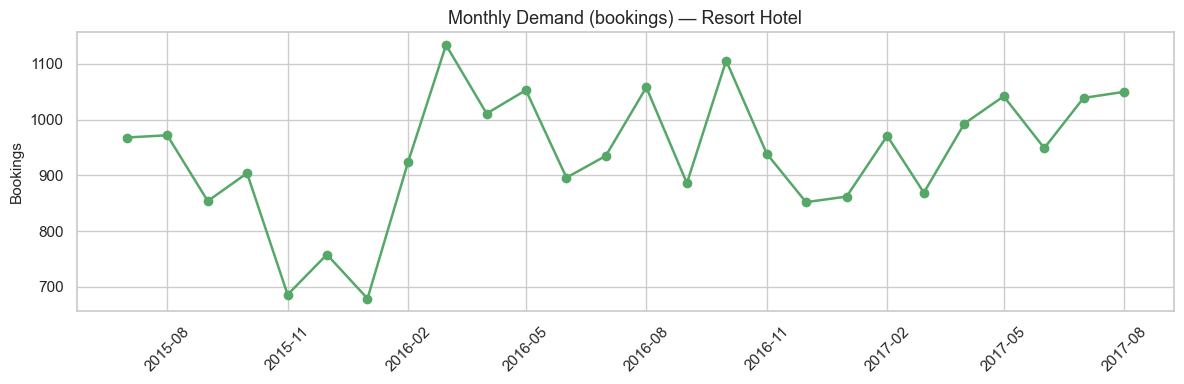

Saved: reports\figures\20\resort\02_seasonal_decompose.png


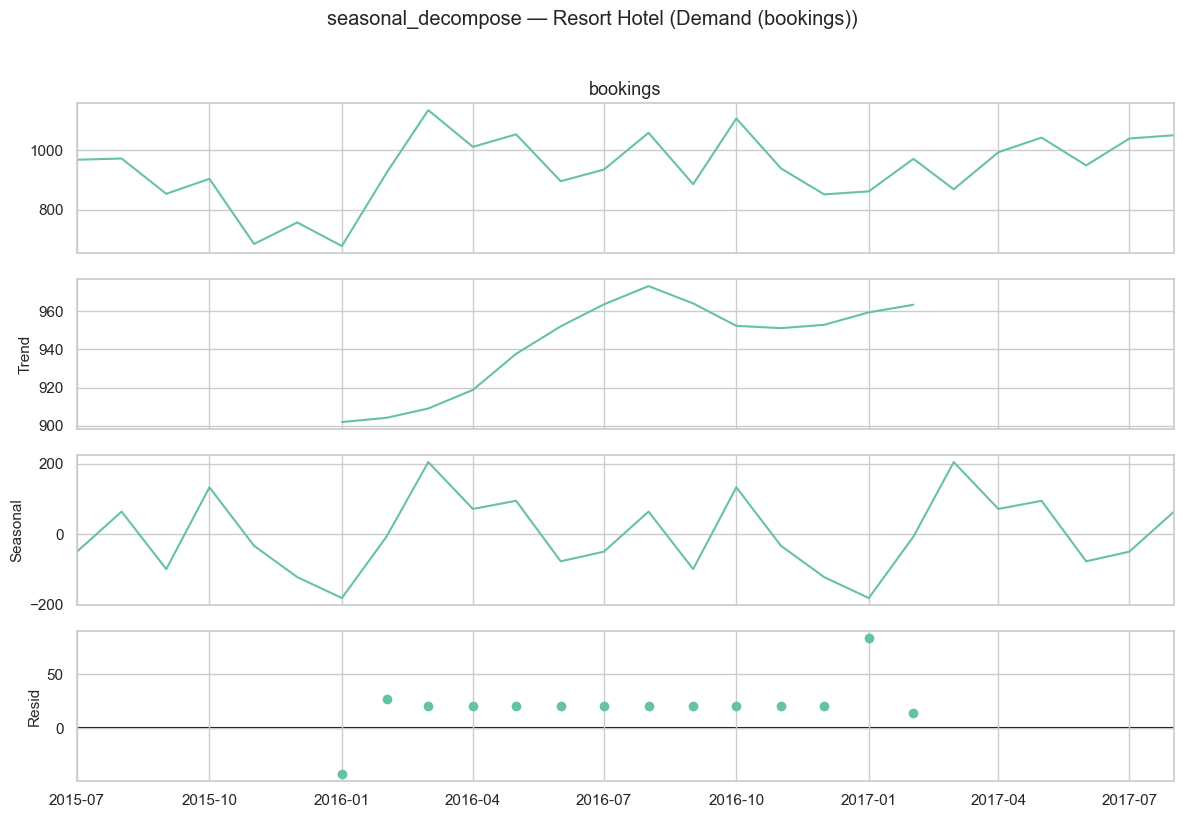

,series,n,adf_stat,adf_pvalue,adf_stationary_5pct,kpss_stat,kpss_pvalue,kpss_stationary_5pct
0,level,26,-3.1385,0.0238,True,0.2454,0.1,True
1,diff1,25,-7.0240,0.0000,True,0.0746,0.1,True
2,seasonal_diff12,14,-2.4481,0.1286,False,0.1728,0.1,True
3,diff1_seasonal12,13,-4.2453,0.0006,True,0.1306,0.1,True


Selected differencing: d=1, D=0 (s=12)
Saved: reports\figures\20\resort\03_acf_pacf.png


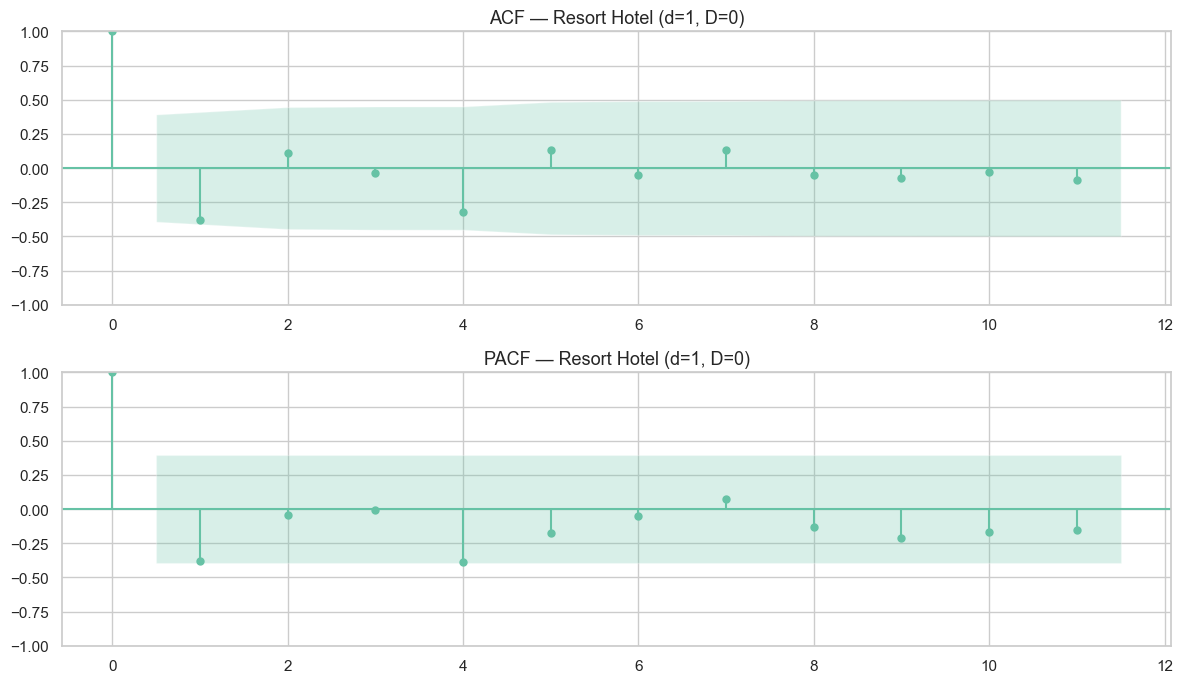

Train: 2015-07-01 → 2017-02-01 (n=20)
Test : 2017-03-01 → 2017-08-01 (n=6)
Fitted 36 usable SARIMAX candidates on train


,order,seasonal_order,p,d,q,P,D,Q,aic,bic,llf
0,"(0, 1, 2)","(1, 0, 1, 12)",0,1,2,1,0,1,49.48,46.41,-19.74
1,"(1, 1, 2)","(1, 0, 1, 12)",1,1,2,1,0,1,50.25,46.57,-19.13
2,"(2, 1, 2)","(1, 0, 1, 12)",2,1,2,1,0,1,52.06,47.77,-19.03
3,"(0, 1, 2)","(0, 0, 1, 12)",0,1,2,0,0,1,53.94,51.49,-22.97
4,"(1, 1, 2)","(0, 0, 1, 12)",1,1,2,0,0,1,55.31,52.24,-22.66
5,"(2, 1, 2)","(0, 0, 1, 12)",2,1,2,0,0,1,57.19,53.50,-22.59
6,"(0, 1, 1)","(1, 0, 1, 12)",0,1,1,1,0,1,65.62,64.06,-28.81
7,"(0, 1, 1)","(0, 0, 1, 12)",0,1,1,0,0,1,66.66,65.48,-30.33
8,"(2, 1, 0)","(1, 0, 0, 12)",2,1,0,1,0,0,66.99,65.43,-29.49
9,"(2, 1, 1)","(1, 0, 0, 12)",2,1,1,1,0,0,67.40,65.45,-28.70


Best SARIMAX by AIC: (0, 1, 2) x (1, 0, 1, 12) | AIC=49.48
                                      SARIMAX Results                                       
Dep. Variable:                             bookings   No. Observations:                   20
Model:             SARIMAX(0, 1, 2)x(1, 0, [1], 12)   Log Likelihood                 -19.742
Date:                              Tue, 21 Jul 2026   AIC                             49.483
Time:                                      20:53:40   BIC                             46.415
Sample:                                  07-01-2015   HQIC                            42.750
                                       - 02-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0001   2155.626  -6.78

<Figure size 1200x800 with 0 Axes>

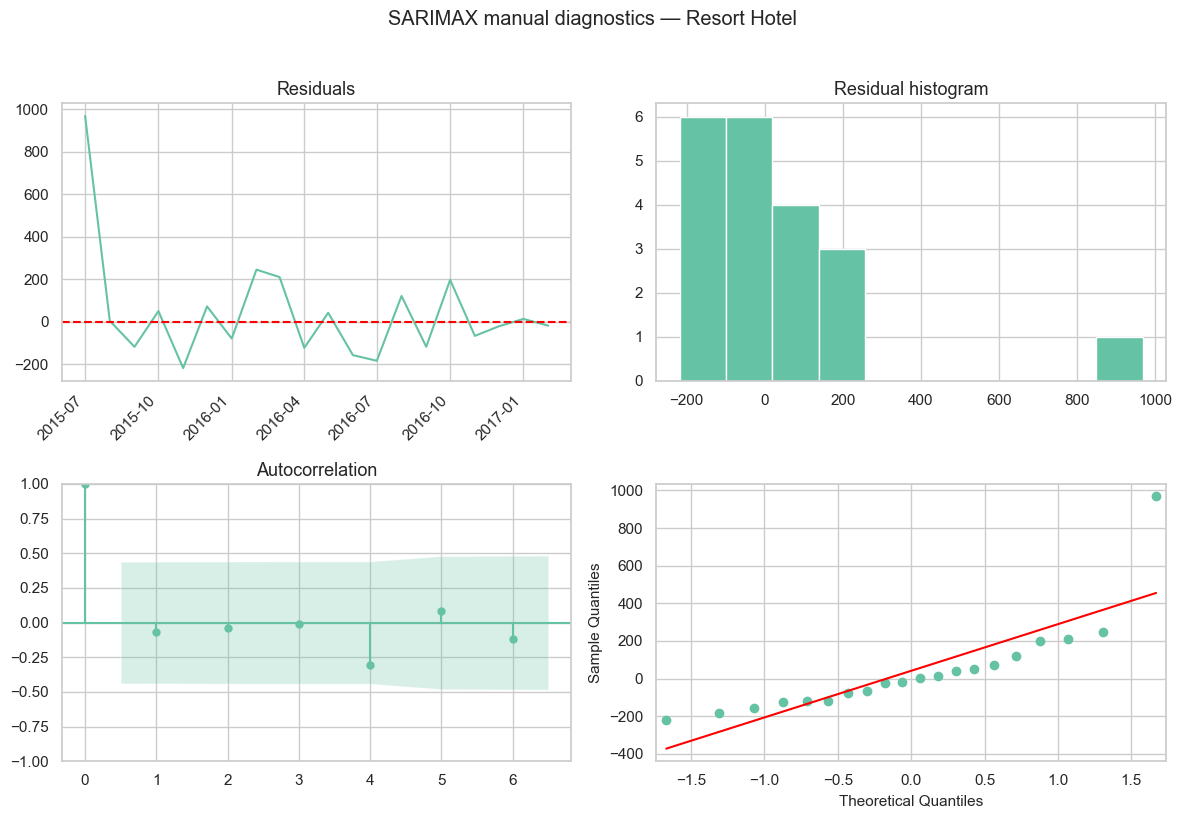

,model,ljungbox_lag6_pvalue,ljungbox_lag12_pvalue,resid_mean,resid_std
0,SARIMAX,0.7584,0.5220,40.9583,254.5523
1,holt_trend,0.0908,0.1875,0.0000,119.5210


,ym,actual,seasonal_naive,holt_trend,sarimax,sarimax_lower95,sarimax_upper95
0,2017-03-01,869.0,1134.0,973.08,1059.09,998.17,1120.02
1,2017-04-01,993.0,1011.0,977.91,1016.09,931.29,1100.90
2,2017-05-01,1042.0,1053.0,982.74,1035.44,950.63,1120.24
3,2017-06-01,949.0,896.0,987.57,963.05,878.25,1047.85
4,2017-07-01,1039.0,935.0,992.39,980.94,896.14,1065.74
5,2017-08-01,1050.0,1058.0,997.22,1002.50,923.23,1081.77


,model,MAE,RMSE,MAPE
0,holt_trend,52.73,59.19,5.46%
1,sarimax,56.56,84.20,6.07%
2,seasonal_naive,76.50,118.57,8.29%


Best holdout model (MAPE): holt_trend
SARIMAX 95% PI coverage on holdout: 83.3%
Saved: reports\figures\20\resort\05_holdout_forecasts.png


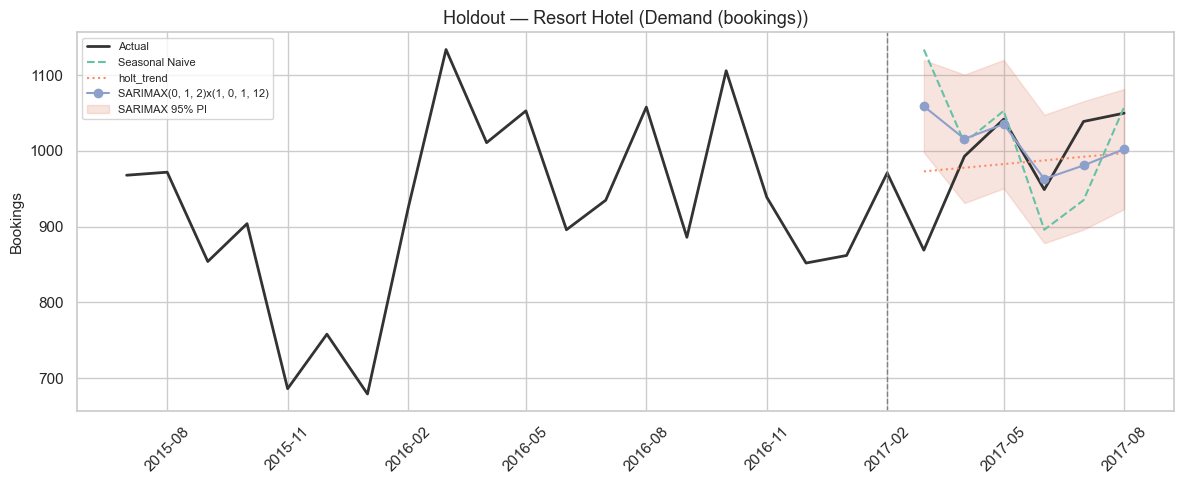

Saved: reports\figures\20\resort\05_holdout_metrics.png


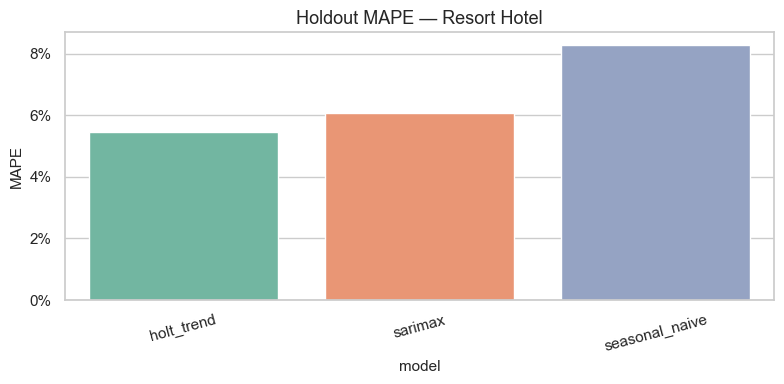

Full-sample exponential smoothing kind: holt_winters_seasonal
Full-sample plot_diagnostics skipped: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.


,hotel,ym,sarimax,sarimax_lower95,sarimax_upper95,holt_winters,holt_kind_full,seasonal_naive,best_holdout_model,sarimax_order,sarimax_seasonal_order
0,Resort Hotel,2017-09-01,992.49,868.62,1116.35,942.41,holt_winters_seasonal,886.0,holt_trend,"(0, 1, 2)","(1, 0, 1, 12)"
1,Resort Hotel,2017-10-01,930.87,800.60,1061.15,1077.36,holt_winters_seasonal,1106.0,holt_trend,"(0, 1, 2)","(1, 0, 1, 12)"
2,Resort Hotel,2017-11-01,954.53,824.26,1084.80,884.83,holt_winters_seasonal,939.0,holt_trend,"(0, 1, 2)","(1, 0, 1, 12)"
3,Resort Hotel,2017-12-01,986.77,856.50,1117.05,877.36,holt_winters_seasonal,852.0,holt_trend,"(0, 1, 2)","(1, 0, 1, 12)"
4,Resort Hotel,2018-01-01,975.56,845.28,1105.83,842.85,holt_winters_seasonal,862.0,holt_trend,"(0, 1, 2)","(1, 0, 1, 12)"
5,Resort Hotel,2018-02-01,971.25,840.98,1101.52,1019.85,holt_winters_seasonal,971.0,holt_trend,"(0, 1, 2)","(1, 0, 1, 12)"


Saved: reports\figures\20\resort\07_forecast_horizon.png


<Figure size 1200x800 with 0 Axes>

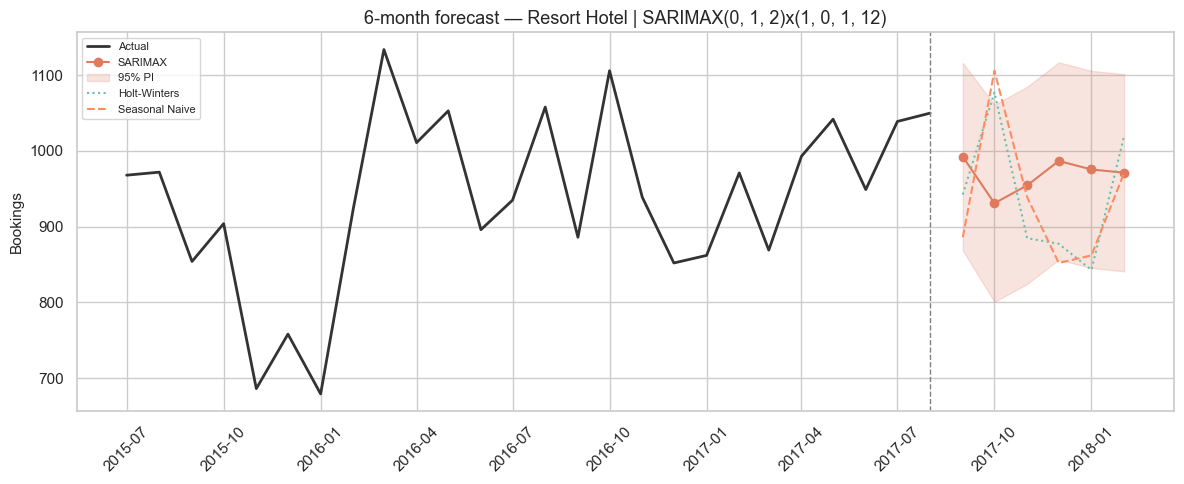

,hotel,ym,forecast_model,forecast,season_index,demand_index,combined_pressure,pricing_stance
0,Resort Hotel,2017-09-01,holt_trend,942.409,0.933,1.011,0.972,"NEUTRAL — hold BAR, tactical weekend premium"
1,Resort Hotel,2017-10-01,holt_trend,1077.355,1.078,1.155,1.116,"NEUTRAL — hold BAR, tactical weekend premium"
2,Resort Hotel,2017-11-01,holt_trend,884.831,0.871,0.949,0.910,"NEUTRAL — hold BAR, tactical weekend premium"
3,Resort Hotel,2017-12-01,holt_trend,877.360,0.863,0.941,0.902,"NEUTRAL — hold BAR, tactical weekend premium"
4,Resort Hotel,2018-01-01,holt_trend,842.848,0.826,0.904,0.865,STIMULATE — promo / early-bird / package
5,Resort Hotel,2018-02-01,holt_trend,1019.850,1.016,1.094,1.055,"NEUTRAL — hold BAR, tactical weekend premium"


Saved: reports\figures\20\resort\08_pricing_stance.png


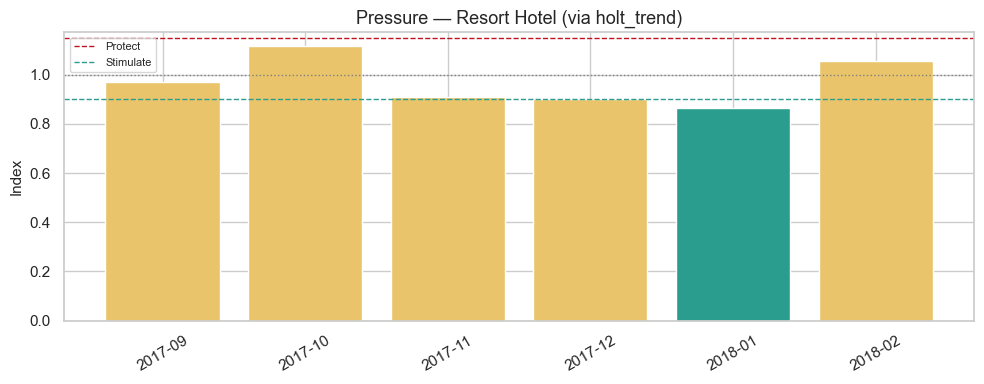

,hotel,metric,value
0,Resort Hotel,n_months,26
1,Resort Hotel,series_sum_or_mean,24390.0
2,Resort Hotel,diff_d,1
3,Resort Hotel,diff_D,0
4,Resort Hotel,sarimax_order,"(0, 1, 2)"
5,Resort Hotel,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,Resort Hotel,sarimax_aic_train,49.48
7,Resort Hotel,best_holdout_model,holt_trend
8,Resort Hotel,best_holdout_mape,0.0546
9,Resort Hotel,naive_holdout_mape,0.0829


In [5]:
results = {}
for hotel in HOTELS:
    y = series_by_hotel[hotel].dropna()
    results[hotel] = run_forecast_pipeline(y, hotel, YLABEL, METRIC_LABEL)


## 10. So sánh City vs Resort


,hotel,best_holdout_model,best_mape,sarimax_mape,naive_mape,sarimax_order,sarimax_seasonal,d,D,pi95_coverage,aic_train
0,City Hotel,seasonal_naive,7.77%,45.14%,7.77%,"(2, 1, 2)","(1, 0, 1, 12)",1,0,0.0%,54.336794
1,Resort Hotel,holt_trend,5.46%,6.07%,8.29%,"(0, 1, 2)","(1, 0, 1, 12)",1,0,83.3%,49.483403


Saved: reports\figures\20\09_compare_forecast_overlay.png


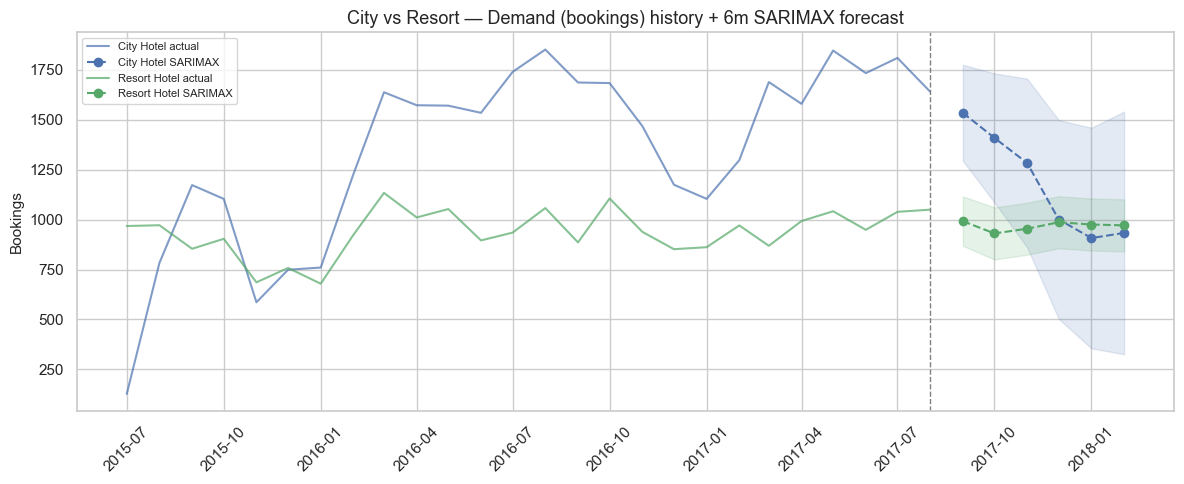

,hotel,ym,forecast_model,forecast,season_index,demand_index,combined_pressure,pricing_stance
0,City Hotel,2017-09-01,seasonal_naive,1687.000000,1.056455,1.246321,1.151388,"PROTECT — raise / harden BAR, limit promo"
1,City Hotel,2017-10-01,seasonal_naive,1684.000000,1.029859,1.244105,1.136982,"NEUTRAL — hold BAR, tactical weekend premium"
2,City Hotel,2017-11-01,seasonal_naive,1469.000000,0.759096,1.085267,0.922182,"NEUTRAL — hold BAR, tactical weekend premium"
3,City Hotel,2017-12-01,seasonal_naive,1175.000000,0.710706,0.868066,0.789386,STIMULATE — promo / early-bird / package
4,City Hotel,2018-01-01,seasonal_naive,1104.000000,0.688543,0.815613,0.752078,STIMULATE — promo / early-bird / package
5,City Hotel,2018-02-01,seasonal_naive,1298.000000,0.933079,0.958936,0.946008,"NEUTRAL — hold BAR, tactical weekend premium"
6,Resort Hotel,2017-09-01,holt_trend,942.409479,0.932865,1.010506,0.971686,"NEUTRAL — hold BAR, tactical weekend premium"
7,Resort Hotel,2017-10-01,holt_trend,1077.355444,1.077620,1.155203,1.116411,"NEUTRAL — hold BAR, tactical weekend premium"
8,Resort Hotel,2017-11-01,holt_trend,884.831001,0.871210,0.948767,0.909989,"NEUTRAL — hold BAR, tactical weekend premium"
9,Resort Hotel,2017-12-01,holt_trend,877.359703,0.863168,0.940756,0.901962,"NEUTRAL — hold BAR, tactical weekend premium"


,hotel,metric,value
0,City Hotel,n_months,26
1,City Hotel,series_sum_or_mean,35137.0
2,City Hotel,diff_d,1
3,City Hotel,diff_D,0
4,City Hotel,sarimax_order,"(2, 1, 2)"
5,City Hotel,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,City Hotel,sarimax_aic_train,54.34
7,City Hotel,best_holdout_model,seasonal_naive
8,City Hotel,best_holdout_mape,0.0777
9,City Hotel,naive_holdout_mape,0.0777


Demand (bookings) — CITY vs RESORT INSIGHTS
- City Hotel: best=seasonal_naive | MAPE=7.8% | SARIMAX(2, 1, 2)x(1, 0, 1, 12) | d=1, D=0
- Resort Hotel: best=holt_trend | MAPE=5.5% | SARIMAX(0, 1, 2)x(1, 0, 1, 12) | d=1, D=0
- Pricing stance nên tách calendar City / Resort (peak & trough khác biên độ).
- Chuỗi ngắn (~26 tháng/hotel) → ưu tiên holdout winner, không chỉ AIC.


In [6]:
# Cross-hotel comparison
rows = []
for hotel, r in results.items():
    rows.append(
        {
            "hotel": hotel,
            "best_holdout_model": r["best_model"],
            "best_mape": r["metrics_df"].iloc[0]["MAPE"],
            "sarimax_mape": r["mape_map"].get("sarimax", np.nan),
            "naive_mape": r["mape_map"].get("seasonal_naive", np.nan),
            "sarimax_order": str(r["best_order"]),
            "sarimax_seasonal": str(r["best_seasonal"]),
            "d": r["d_order"],
            "D": r["D_order"],
            "pi95_coverage": r["inside"],
            "aic_train": r["aic"],
        }
    )
compare_df = pd.DataFrame(rows)
display(compare_df.style.format({"best_mape": "{:.2%}", "sarimax_mape": "{:.2%}", "naive_mape": "{:.2%}", "pi95_coverage": "{:.1%}"}))
compare_df.to_csv(FIG_DIR / "compare_city_vs_resort.csv", index=False)

# Overlay next-6m SARIMAX forecasts
fig, ax = plt.subplots(figsize=(12, 5))
for hotel, r in results.items():
    y = r["y"]
    fc = r["forecast_df"]
    ax.plot(y.index, y.values, color=HOTEL_COLORS[hotel], lw=1.5, alpha=0.7, label=f"{hotel} actual")
    ax.plot(fc["ym"], fc["sarimax"], marker="o", color=HOTEL_COLORS[hotel], ls="--", label=f"{hotel} SARIMAX")
    ax.fill_between(
        fc["ym"], fc["sarimax_lower95"], fc["sarimax_upper95"],
        color=HOTEL_COLORS[hotel], alpha=0.15,
    )
ax.axvline(list(results.values())[0]["y"].index.max(), color="gray", ls="--", lw=1)
ax.set_title(f"City vs Resort — {METRIC_LABEL} history + 6m SARIMAX forecast")
ax.set_ylabel(YLABEL)
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
path = FIG_DIR / "09_compare_forecast_overlay.png"
plt.savefig(path, dpi=140, bbox_inches="tight")
print(f"Saved: {path.relative_to(ROOT)}")
plt.show()

pricing_all = pd.concat([r["pricing"] for r in results.values()], ignore_index=True)
display(pricing_all)
pricing_all.to_csv(FIG_DIR / "pricing_stance_city_vs_resort.csv", index=False)

kpi_all = pd.concat([r["kpi"] for r in results.values()], ignore_index=True)
display(kpi_all)
kpi_all.to_csv(FIG_DIR / "kpi_summary_city_vs_resort.csv", index=False)

print("=" * 72)
print(f"{METRIC_LABEL} — CITY vs RESORT INSIGHTS")
print("=" * 72)
for hotel, r in results.items():
    print(
        f"- {hotel}: best={r['best_model']} | MAPE={r['metrics_df'].iloc[0]['MAPE']:.1%} | "
        f"SARIMAX{r['best_order']}x{r['best_seasonal']} | d={r['d_order']}, D={r['D_order']}"
    )
print("- Pricing stance nên tách calendar City / Resort (peak & trough khác biên độ).")
print("- Chuỗi ngắn (~26 tháng/hotel) → ưu tiên holdout winner, không chỉ AIC.")
